Учебная практика
Адаптированная архитектура InceptionTime для многометочной классификации 12-канальных ЭКГ-сигналов PTB-XL.

In [3]:
# Установка библиотек для чтения ECG данных и обучения модели
!pip install wfdb tsai -q > /dev/null 2>&1;

In [4]:
%%writefile config.py
from pathlib import Path

# Основные настройки эксперимента
config = {
    'seed': 123,
    'lr': 0.0001,
    'batch_size': 64,
    'epochs': 25,
    'sampling_rate': 100,
    'model_name': 'InceptionTimeECG'
}

# Порядок классов
target_classes = sorted(['CD', 'HYP', 'MI', 'NORM', 'STTC'])
manual_weights_values = [1.0, 2.0, 2.0, 1.0, 1.5]

# Путь для сохранения результатов
WORK_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
MODELS_DIR = WORK_DIR / 'models'
FIGURES_DIR = WORK_DIR / 'figures'
TABLES_DIR = WORK_DIR / 'tables'
ARTIFACTS_DIR = WORK_DIR / 'artifacts'

# Цвета классов
class_colors = {
    'CD': '#1f77b4',    # синий
    'HYP': '#ff7f0e',   # оранжевый
    'MI': '#2ca02c',    # зелёный
    'NORM': '#9467bd',  # фиолетовый
    'STTC': '#d62728'   # красный
}

# Дополнительные стили нужны, чтобы линии отличались при чёрно-белой печати
line_styles = {
    'CD': '-',
    'HYP': '--',
    'MI': ':',
    'NORM': '-.',
    'STTC': (0, (8, 3, 1, 3, 1, 3, 1, 3))
}

Writing config.py


In [5]:
%%writefile model.py
import torch
import torch.nn as nn

# Ручная архитектура InceptionTime
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes=[9, 19, 39], bottleneck_channels=32):
        super().__init__()
        
        # Bottleneck 1x1 уменьшает число каналов перед свёртками
        self.use_bottleneck = in_channels > 1
        if self.use_bottleneck:
            self.bottleneck = nn.Conv1d(in_channels, bottleneck_channels, kernel_size=1, bias=False)
            in_channels = bottleneck_channels
            
        # Несколько свёрток с разными размерами ядра позволяют искать признаки на разных временных масштабах ЭКГ-сигнала
        self.convs = nn.ModuleList()
        for k in kernel_sizes:
            self.convs.append(nn.Conv1d(in_channels, out_channels, kernel_size=k, padding=k//2, bias=False))

        # Ветка с max pooling помогает учитывать локальные максимумы сигнала
        self.maxconv = nn.Sequential(
            nn.MaxPool1d(3, stride=1, padding=1),
            nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False)
        )

        # После объединения всех веток: три свёрточные ветки + одна ветка max pooling
        self.bn = nn.BatchNorm1d(out_channels * 4)
        self.act = nn.ReLU()

    def forward(self, x):
        input_tensor = x
        # Если используется bottleneck, сначала пропускаем сигнал через 1x1 свёртку
        if self.use_bottleneck:
            input_tensor = self.bottleneck(input_tensor)
        # Применяем все параллельные ветки Inception-блока
        outputs = [conv(input_tensor) for conv in self.convs]
        outputs.append(self.maxconv(input_tensor))
        # Объединяем признаки, полученные разными ветками, по каналам
        x = torch.cat(outputs, dim=1)
        return self.act(self.bn(x))

# Shortcut нужен для остаточной связи между блоками. Уменьшает проблему затухания градиентов
class Shortcut(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Свёртка 1x1 приводит число каналов к нужному размеру,чтобы можно было сложить shortcut и выход Inception-блоков
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm1d(out_channels)

    def forward(self, x):
        return self.bn(self.conv(x))

# Основная модель InceptionTime для классификации 12-канальной ЭКГ
class InceptionTimeECG(nn.Module):
    def __init__(self, c_in=12, c_out=5, depth=6, nb_filters=32):
        super().__init__()
        self.blocks, self.shortcuts = nn.ModuleList(), nn.ModuleList()
        # curr_in — текущее число входных каналов,
        # curr_out — число каналов после одного Inception-блока
        curr_in, curr_out = c_in, nb_filters * 4
        for d in range(depth):
            self.blocks.append(InceptionModule(curr_in, nb_filters))
            # Остаточная связь добавляется после каждого третьего Inception-блока
            if d % 3 == 2:
                s_in = c_in if d == 2 else curr_out
                self.shortcuts.append(Shortcut(s_in, curr_out))
            else:
                self.shortcuts.append(None)
            curr_in = curr_out
        # Global Average Pooling переводит временную последовательность в один вектор признаков для каждого объекта
        self.gap = nn.AdaptiveAvgPool1d(1)
        # Финальный полносвязный слой выдаёт 5 логитов, по одному для каждого диагностического суперкласса
        self.fc = nn.Linear(curr_out, c_out)

    def forward(self, x):
        res = x
        for i, block in enumerate(self.blocks):
            x = block(x)
            # Если для текущего блока задан shortcut, добавляем остаточную связь
            if self.shortcuts[i] is not None:
                res = self.shortcuts[i](res)
                x = torch.relu(x + res)
                res = x
        return self.fc(self.gap(x).squeeze(-1))


Writing model.py


In [6]:
%%writefile data_utils.py
import os
import ast
import pickle
import warnings
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import wfdb
from tqdm.notebook import tqdm
from sklearn.preprocessing import MultiLabelBinarizer
from tsai.all import get_ts_dls, TSStandardize

# Подготовка данных
def seed_everything(seed=123):
    # Фиксируем seed, чтобы результаты были воспроизводимыми
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def find_base_path():
    # Путь к датасету в Kaggle 
    base_path = Path('')
    if os.path.exists('/kaggle/input'):
        for root, _, files in os.walk('/kaggle/input'):
            if 'ptbxl_database.csv' in files:
                base_path = Path(root)
                break
    else:
        base_path = Path('.')
    return base_path


def aggregate_diagnostic(y_dic, agg_df):
    # Переводим SCP-коды в диагностические суперклассы PTB-XL
    tmp = set()
    for key in y_dic.keys():
        if key in agg_df.index:
            d_class = agg_df.loc[key].diagnostic_class
            if pd.notna(d_class):
                tmp.add(d_class)
    # Возвращаем список классов, потому что у одной ЭКГ может быть несколько меток
    return list(tmp)


def load_signals(df, path, sr):
    # Загружаем сами ECG-сигналы. Если запись не прочиталась, строка остаётся нулевой
    filenames = df['filename_lr'].tolist()
    if len(filenames) == 0:
        return np.zeros((1, 12, sr * 10), dtype=np.float32)

    X = np.zeros((len(filenames), 12, sr * 10), dtype=np.float32)
    for i, fname in enumerate(tqdm(filenames, desc='Загрузка сигналов')):
        try:
            sig, _ = wfdb.rdsamp(str(path / fname))
            # wfdb загружает сигнал как длина x каналы, а для Conv1d нужен формат каналы x длина
            X[i] = sig.T
        except Exception:
            pass
    return X

# Подготовка данных
def prepare_data(config, target_classes, artifacts_dir):
    print('Поиск и загрузка данных')
    base_path = find_base_path()

    if not (base_path / 'ptbxl_database.csv').exists():
        raise FileNotFoundError('Файл ptbxl_database.csv не найден.')

    # Основная таблица PTB-XL с информацией о записях
    df = pd.read_csv(base_path / 'ptbxl_database.csv', index_col='ecg_id')
    
    df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

    # Таблица с расшифровкой SCP-кодов
    agg_df = pd.read_csv(base_path / 'scp_statements.csv', index_col=0)
    agg_df = agg_df[agg_df.diagnostic == 1]

    # Для каждой ЭКГ получаем список диагностических суперклассов
    df['diagnostic_superclass'] = df.scp_codes.apply(lambda x: aggregate_diagnostic(x, agg_df))
    # Убираем записи без диагностических меток
    df = df[df.diagnostic_superclass.apply(len) > 0].reset_index(drop=True)

    mlb = MultiLabelBinarizer(classes=target_classes)
    y_encoded = mlb.fit_transform(df['diagnostic_superclass']).astype(np.float32)

    artifacts_dir.mkdir(parents=True, exist_ok=True)
    with open(artifacts_dir / 'mlb.pkl', 'wb') as f:
        pickle.dump(mlb, f)

    # Загружаем сами сигналы ЭКГ
    X = load_signals(df, base_path, config['sampling_rate'])

    # Разбиение датасета по strat_fold: 1-8 — обучение, 9 — валидация, 10 — тест
    train_idx = df[df.strat_fold <= 8].index.tolist()
    val_idx = df[df.strat_fold == 9].index.tolist()
    test_idx = df[df.strat_fold == 10].index.tolist()

    # TSStandardize(by_sample=True) стандартизует каждый сигнал отдельно
    dls = get_ts_dls(
        X,
        y_encoded,
        splits=(train_idx, val_idx),
        bs=config['batch_size'],
        batch_tfms=[TSStandardize(by_sample=True)]
    )

    return df, X, y_encoded, train_idx, val_idx, test_idx, dls, mlb


def make_folders(*folders):
    for folder in folders:
        Path(folder).mkdir(parents=True, exist_ok=True)


def setup_notebook(seed=123):
    seed_everything(seed)
    warnings.filterwarnings('ignore')


Writing data_utils.py


In [7]:
%%writefile train_eval.py
import pickle

import torch
import numpy as np
import pandas as pd
from IPython.display import display
from fastai.callback.all import EarlyStoppingCallback, SaveModelCallback
from tsai.all import Learner, BCEWithLogitsLossFlat, accuracy_multi, F1ScoreMulti, TSDatasets
from sklearn.metrics import f1_score, precision_score, recall_score

from model import InceptionTimeECG

# Обучение и оценка
def create_learner(dls, config, target_classes, manual_weights_values):
    device = dls.device

    manual_weights = torch.tensor(manual_weights_values).to(device)
    print(f'Используемые веса классов: {target_classes} -> {manual_weights.cpu().numpy()}')

    model = InceptionTimeECG(c_in=12, c_out=5)
    loss_func = BCEWithLogitsLossFlat(pos_weight=manual_weights)

    # Объединяем модель, данные, функцию потерь и метрики для обучения
    learn = Learner(
        dls,
        model,
        metrics=[accuracy_multi, F1ScoreMulti(average='macro')],
        loss_func=loss_func,
        wd=0.1,  # регуляризация
        cbs=[EarlyStoppingCallback(patience=8), SaveModelCallback(fname=config['model_name'])]
    )
    return learn, model


def get_history(learn):
    # Достаем историю обучения из recorder, чтобы потом построить графики
    history = pd.DataFrame(learn.recorder.values)
    metric_names = learn.recorder.metric_names[1:-1]

    if len(history.columns) == len(metric_names):
        history.columns = metric_names
    else:
        n_common = min(len(metric_names), len(history.columns))
        new_cols = list(metric_names[:n_common]) + [f'extra_{i}' for i in range(len(history.columns) - n_common)]
        history.columns = new_cols
    return history


def evaluate_model(probs, targets, thresholds=None):
    # если thresholds не переданы, подбираем их по validation;
    # если переданы, просто применяем готовые пороги
    final_preds = np.zeros_like(probs)
    if thresholds is None:
        # Для каждого класса ищем такой threshold, который даёт лучшую F1-меру
        thresholds = np.zeros(5)
        for i in range(5):
            best_t, best_f1 = 0.5, 0
            for t in np.arange(0.1, 0.9, 0.05):
                score = f1_score(targets[:, i], (probs[:, i] > t).astype(int))
                if score > best_f1:
                    best_f1, best_t = score, t
            thresholds[i] = best_t
            final_preds[:, i] = (probs[:, i] > best_t).astype(int)
        return thresholds, final_preds
    else:
        for i in range(5):
            final_preds[:, i] = (probs[:, i] > thresholds[i]).astype(int)
        return final_preds


def count_metrics(targets, preds):
    # Метрики
    return {
        'Accuracy': (preds == targets).mean(),
        'Precision': precision_score(targets, preds, average='macro'),
        'Recall': recall_score(targets, preds, average='macro'),
        'F1 Score': f1_score(targets, preds, average='macro')
    }


def make_result_tables(val_metrics, test_metrics):
    # Таблицы сравнения с RNN, GRU и LSTM
    sander_val = {
        'Model': ['RNN', 'GRU', 'LSTM'],
        'Accuracy': [0.7608, 0.8684, 0.8789],
        'Precision': [0.0125, 0.8228, 0.8350],
        'Recall': [0.0708, 0.5514, 0.5833],
        'F1 Score': [0.0929, 0.6478, 0.6754]
    }
    sander_test = {
        'Model': ['RNN', 'GRU', 'LSTM'],
        'Accuracy': [0.7608, 0.8612, 0.8749],
        'Precision': [0.0125, 0.8202, 0.8247],
        'Recall': [0.0708, 0.5198, 0.5663],
        'F1 Score': [0.0929, 0.6200, 0.6589]
    }

    df_val_final = pd.concat([
        pd.DataFrame(sander_val),
        pd.DataFrame({'Model': ['InceptionTime'], **{k: [v] for k, v in val_metrics.items()}})
    ], ignore_index=True)

    df_test_final = pd.concat([
        pd.DataFrame(sander_test),
        pd.DataFrame({'Model': ['InceptionTime'], **{k: [v] for k, v in test_metrics.items()}})
    ], ignore_index=True)

    return df_val_final, df_test_final


def run_train_and_eval(X, y_encoded, test_idx, dls, config, target_classes, manual_weights_values):
    print('Обучение модели')
    learn, model = create_learner(dls, config, target_classes, manual_weights_values)
    learn.fit_one_cycle(config['epochs'], lr_max=config['lr'])

    history = get_history(learn)

    print('Оценка результатов')
    val_probs, val_targs = learn.get_preds(ds_idx=1)
    best_thresholds, val_preds = evaluate_model(val_probs.numpy(), val_targs.numpy())
    val_metrics = count_metrics(val_targs.numpy(), val_preds)

    test_ds = TSDatasets(X[test_idx], y_encoded[test_idx])
    test_dl = dls.valid.new(test_ds)
    test_probs, test_targs = learn.get_preds(dl=test_dl)
    test_preds = evaluate_model(test_probs.numpy(), test_targs.numpy(), thresholds=best_thresholds)
    test_metrics = count_metrics(test_targs.numpy(), test_preds)

    df_val_final, df_test_final = make_result_tables(val_metrics, test_metrics)

    print('\nТаблица 1. Результаты валидации:')
    display(df_val_final)
    print('\nТаблица 2. Результаты тестирования:')
    display(df_test_final)

    results = {
        'learn': learn,
        'model': model,
        'history': history,
        'best_thresholds': best_thresholds,
        'val_probs': val_probs.numpy(),
        'val_targs': val_targs.numpy(),
        'val_preds': val_preds,
        'test_probs': test_probs.numpy(),
        'test_targs': test_targs.numpy(),
        'test_preds': test_preds,
        'df_val_final': df_val_final,
        'df_test_final': df_test_final,
        # Эти данные нужны для отдельного быстрого построения графиков
        'y_encoded': y_encoded,
        'target_classes': target_classes
    }
    return results


def save_results(results, mlb, config, models_dir, tables_dir, artifacts_dir):
    # Сохраняю всё, что может понадобиться после обучения
    models_dir.mkdir(parents=True, exist_ok=True)
    tables_dir.mkdir(parents=True, exist_ok=True)
    artifacts_dir.mkdir(parents=True, exist_ok=True)

    learn = results['learn']
    model = results['model']
    best_thresholds = results['best_thresholds']

    # 1) Полный fastai Learner
    learner_path = models_dir / f"{config['model_name']}_learner.pkl"
    learn.export(learner_path)

    # 2) Полная PyTorch-модель
    torch.save(model, models_dir / f"{config['model_name']}_full_torch_model.pt")

    # 3) Checkpoint со state_dict и порогами
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config,
        'thresholds': best_thresholds
    }, models_dir / f"{config['model_name']}_checkpoint.pt")

    np.save(artifacts_dir / 'best_thresholds.npy', best_thresholds)
    with open(artifacts_dir / 'mlb.pkl', 'wb') as f:
        pickle.dump(mlb, f)

    results['history'].to_csv(tables_dir / 'training_history.csv', index=False)
    results['df_val_final'].to_csv(tables_dir / 'validation_results.csv', index=False)
    results['df_test_final'].to_csv(tables_dir / 'test_results.csv', index=False)

    # Отдельно сохраняю данные для графиков, чтобы потом менять оформление рисунков без повторного обучения модели
    plot_data = {
        'y_encoded': results['y_encoded'],
        'history': results['history'],
        'test_targs': results['test_targs'],
        'test_preds': results['test_preds'],
        'test_probs': results['test_probs'],
        'target_classes': results['target_classes']
    }

    with open(artifacts_dir / 'plot_data.pkl', 'wb') as f:
        pickle.dump(plot_data, f)

    print(f'Модель и результаты сохранены в: {models_dir}')

Writing train_eval.py


In [8]:
# Запуск эксперимента
from config import (
    config, target_classes, manual_weights_values,
    MODELS_DIR, FIGURES_DIR, TABLES_DIR, ARTIFACTS_DIR
)
from data_utils import setup_notebook, make_folders, prepare_data
from train_eval import run_train_and_eval, save_results

setup_notebook(config['seed'])
make_folders(MODELS_DIR, FIGURES_DIR, TABLES_DIR, ARTIFACTS_DIR)

# 1. Данные
df, X, y_encoded, train_idx, val_idx, test_idx, dls, mlb = prepare_data(
    config=config,
    target_classes=target_classes,
    artifacts_dir=ARTIFACTS_DIR
)

# 2. Обучение и оценка
results = run_train_and_eval(
    X=X,
    y_encoded=y_encoded,
    test_idx=test_idx,
    dls=dls,
    config=config,
    target_classes=target_classes,
    manual_weights_values=manual_weights_values
)

# 3. Сохранение модели, таблиц и данных для графиков
save_results(
    results=results,
    mlb=mlb,
    config=config,
    models_dir=MODELS_DIR,
    tables_dir=TABLES_DIR,
    artifacts_dir=ARTIFACTS_DIR
)

Поиск и загрузка данных


Загрузка сигналов:   0%|          | 0/21388 [00:00<?, ?it/s]

Обучение модели
Используемые веса классов: ['CD', 'HYP', 'MI', 'NORM', 'STTC'] -> [1.  2.  2.  1.  1.5]


epoch,train_loss,valid_loss,accuracy_multi,f1_score,time
0,0.710861,0.678100,0.712582,0.526943,00:28
1,0.557272,0.536887,0.827959,0.626729,00:28
2,0.450535,0.457575,0.851911,0.621220,00:30
3,0.396886,0.417444,0.861696,0.666307,00:31
4,0.378774,0.407549,0.854613,0.664050,00:32
5,0.364169,0.402739,0.863467,0.684376,00:31
6,0.346378,0.401377,0.862162,0.683651,00:32
7,0.341915,0.393780,0.867288,0.687909,00:32
8,0.331542,0.392438,0.870270,0.687586,00:31
9,0.323278,0.385299,0.871761,0.703220,00:31


Better model found at epoch 0 with valid_loss value: 0.6781002283096313.
Better model found at epoch 1 with valid_loss value: 0.5368871688842773.
Better model found at epoch 2 with valid_loss value: 0.45757508277893066.
Better model found at epoch 3 with valid_loss value: 0.41744449734687805.
Better model found at epoch 4 with valid_loss value: 0.40754929184913635.
Better model found at epoch 5 with valid_loss value: 0.4027388095855713.
Better model found at epoch 6 with valid_loss value: 0.4013773798942566.
Better model found at epoch 7 with valid_loss value: 0.39377984404563904.
Better model found at epoch 8 with valid_loss value: 0.39243799448013306.
Better model found at epoch 9 with valid_loss value: 0.3852987289428711.
Better model found at epoch 12 with valid_loss value: 0.3751952648162842.
No improvement since epoch 12: early stopping
Оценка результатов



Таблица 1. Результаты валидации:


,Model,Accuracy,Precision,Recall,F1 Score
0,RNN,0.760800,0.012500,0.070800,0.09290
1,GRU,0.868400,0.822800,0.551400,0.64780
2,LSTM,0.878900,0.835000,0.583300,0.67540
3,InceptionTime,0.871855,0.702998,0.737632,0.71882



Таблица 2. Результаты тестирования:


,Model,Accuracy,Precision,Recall,F1 Score
0,RNN,0.760800,0.012500,0.070800,0.092900
1,GRU,0.861200,0.820200,0.519800,0.620000
2,LSTM,0.874900,0.824700,0.566300,0.658900
3,InceptionTime,0.871918,0.704843,0.736938,0.719501


Модель и результаты сохранены в: /kaggle/working/models


plots.py обновлён
Используем данные из памяти и сохраняем plot_data.pkl


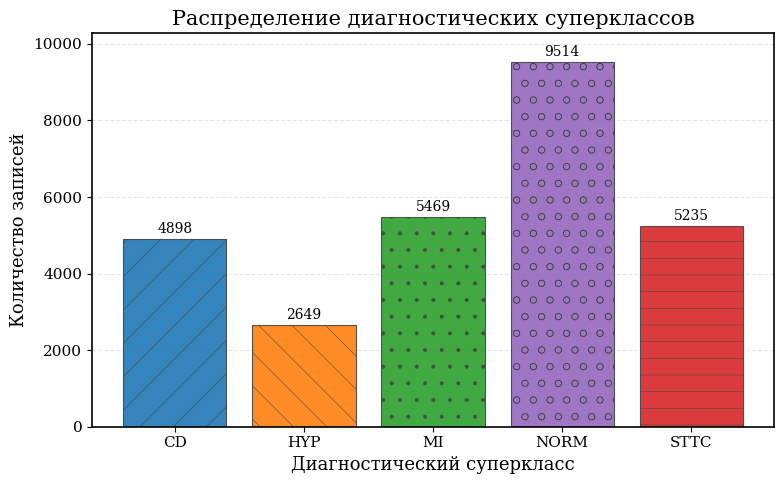

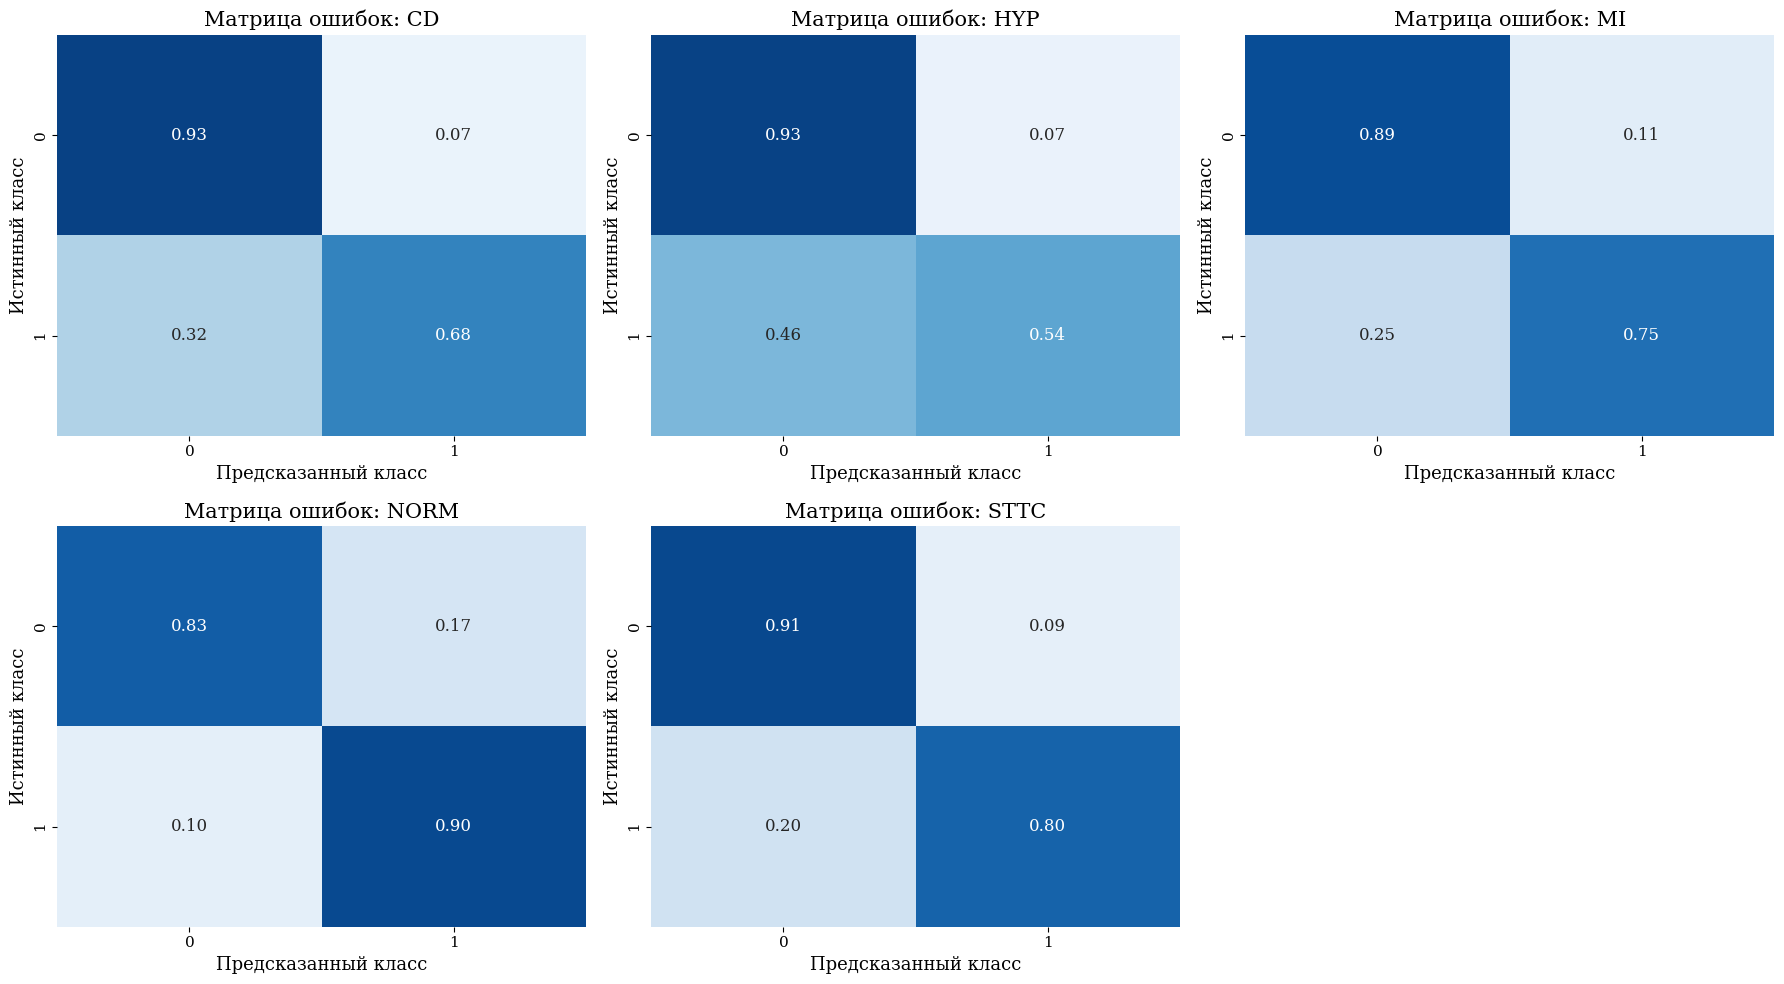

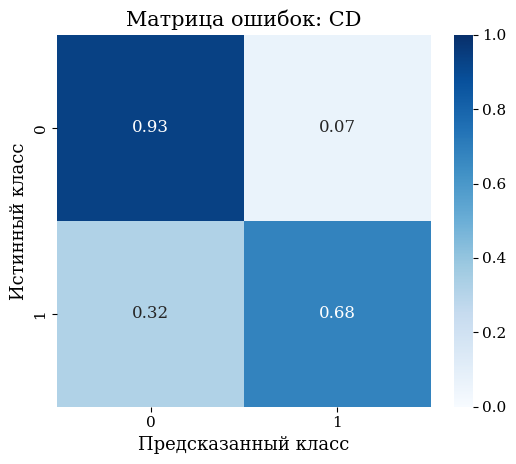

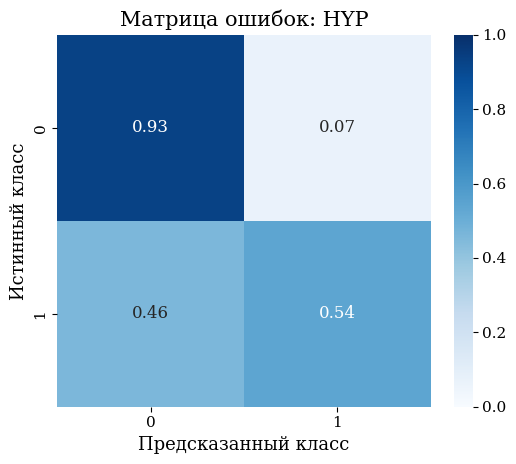

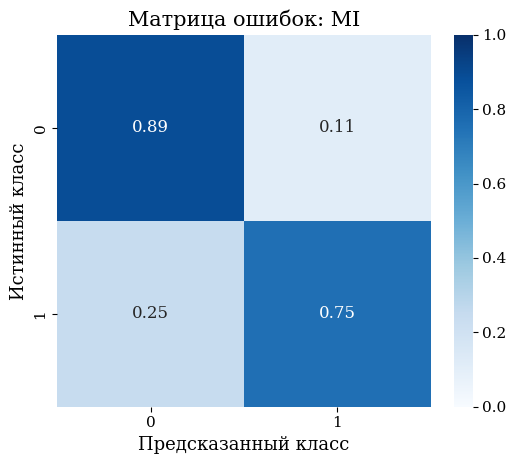

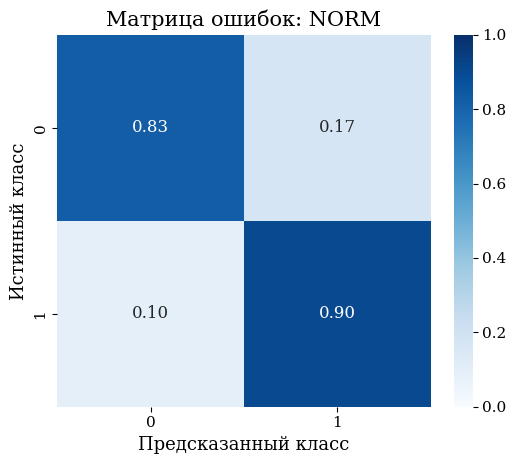

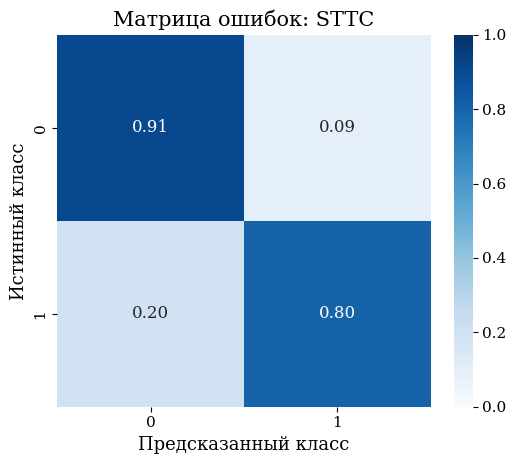

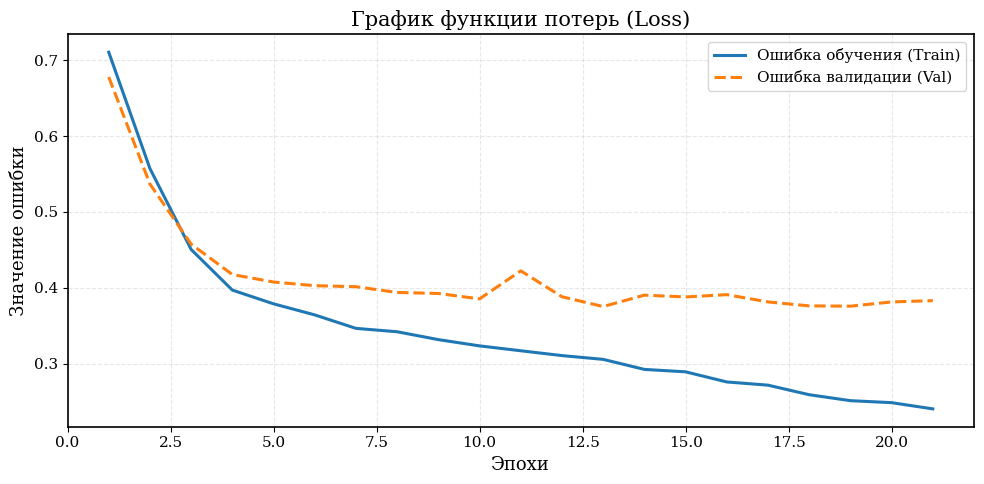

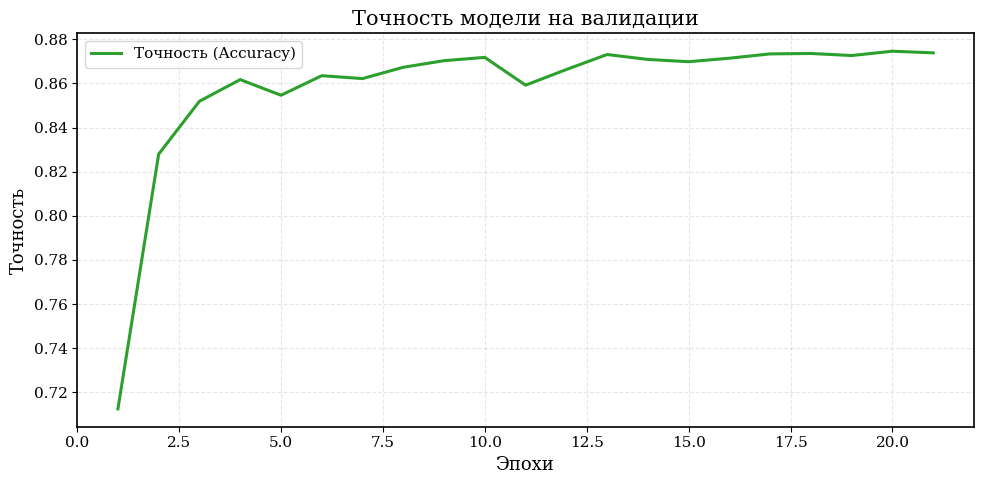

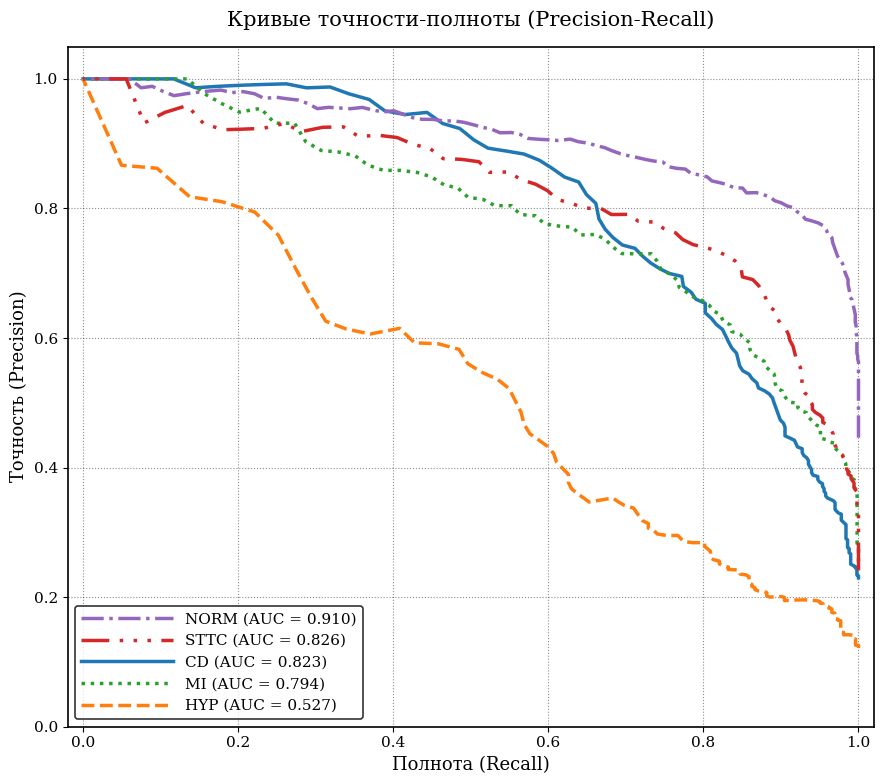

Графики сохранены в: /kaggle/working/figures


In [9]:
# Графики 
from pathlib import Path
import sys
import pickle

plots_code = r'''
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager
from matplotlib.patches import Patch
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score


# Цвета классов: классическая палитра matplotlib
# Эти же цвета используются на гистограмме и на PR-кривых
class_colors = {
    'CD': '#1f77b4',      # синий
    'HYP': '#ff7f0e',     # оранжевый
    'MI': '#2ca02c',      # зелёный
    'NORM': '#9467bd',    # фиолетовый
    'STTC': '#d62728'     # красный
}

# Стили линий для чёрно-белой печати.
line_styles = {
    'CD': '-',
    'HYP': '--',
    'MI': ':',
    'NORM': '-.',
    'STTC': (0, (8, 3, 1, 3, 1, 3, 1, 3))
}


def to_numpy(x):
    # Чтобы функции работали и с numpy-массивами, и с torch-тензорами
    if hasattr(x, 'detach'):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def get_report_font():
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}

    if 'Times New Roman' in available_fonts:
        return 'Times New Roman'

    return 'DejaVu Serif'

def setup_plot_style():
    # Единый стиль для всех рисунков
    report_font = get_report_font()

    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': [report_font, 'Times New Roman', 'DejaVu Serif'],
        'font.size': 12,

        'axes.titlesize': 15,
        'axes.labelsize': 13,
        'legend.fontsize': 11,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,

        'axes.edgecolor': 'black',
        'axes.linewidth': 1.2,

        'grid.alpha': 0.3,
        'grid.linestyle': '--',

        'figure.facecolor': 'white',
        'axes.facecolor': 'white',

        'axes.unicode_minus': False,

        # Тонкая ненавязчивая штриховка для гистограммы
        'hatch.linewidth': 0.4,

        # Для векторных файлов текст остаётся текстом
        'svg.fonttype': 'none',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })


def save_fig(fig, name, figures_dir):
    # PNG — для отчёта, SVG — векторный вариант
    figures_dir.mkdir(parents=True, exist_ok=True)

    fig.savefig(figures_dir / f'{name}.png', dpi=600, bbox_inches='tight')
    fig.savefig(figures_dir / f'{name}.svg', bbox_inches='tight')

def plot_class_distribution(y_encoded, target_classes, figures_dir):
    setup_plot_style()

    y_encoded = to_numpy(y_encoded)
    counts = y_encoded.sum(axis=0)

    # Очень лёгкая штриховка для различимости в ч/б
    light_hatches = {
        'CD': '/',
        'HYP': '\\',
        'MI': '.',
        'NORM': 'o',
        'STTC': '-'
    }

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        target_classes,
        counts,
        color=[class_colors[cls] for cls in target_classes],
        edgecolor='#444444',
        linewidth=0.8,
        alpha=0.9
    )

    for bar, cls, count in zip(bars, target_classes, counts):
        bar.set_hatch(light_hatches[cls])

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            str(int(count)),
            ha='center',
            va='bottom',
            fontsize=10
        )
    # Чтобы числа над столбцами не прижимались к границе рисунка
    ax.set_ylim(0, max(counts) * 1.08)
    
    ax.set_title('Распределение диагностических суперклассов')
    ax.set_xlabel('Диагностический суперкласс')
    ax.set_ylabel('Количество записей')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    save_fig(fig, 'class_distribution', figures_dir)
    plt.show()

def plot_confusion_matrices(test_targs, test_preds, target_classes, figures_dir):
    setup_plot_style()

    test_targs = to_numpy(test_targs)
    test_preds = to_numpy(test_preds)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, cls in enumerate(target_classes):
        cm = confusion_matrix(
            test_targs[:, i],
            test_preds[:, i],
            normalize='true'
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            ax=axes[i],
            cbar=False,
            vmin=0,
            vmax=1
        )

        # Подписи
        axes[i].set_title(f'Матрица ошибок: {cls}')
        axes[i].set_ylabel('Истинный класс')
        axes[i].set_xlabel('Предсказанный класс')

    fig.delaxes(axes[5])

    plt.tight_layout()
    save_fig(fig, 'confusion_matrices', figures_dir)
    plt.show()


def plot_loss(history, figures_dir):
    setup_plot_style()

    fig, ax = plt.subplots(figsize=(10, 5))

    if 'train_loss' in history.columns:
        ax.plot(
            history.index + 1,
            history['train_loss'],
            label='Ошибка обучения (Train)',
            color='#1f77b4',
            linestyle='-',
            linewidth=2.2
        )

    if 'valid_loss' in history.columns:
        ax.plot(
            history.index + 1,
            history['valid_loss'],
            label='Ошибка валидации (Val)',
            color='#ff7f0e',
            linestyle='--',
            linewidth=2.2
        )

    ax.set_title('График функции потерь (Loss)')
    ax.set_xlabel('Эпохи')
    ax.set_ylabel('Значение ошибки')
    ax.legend(frameon=True)
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    save_fig(fig, 'loss_history', figures_dir)
    plt.show()

def plot_accuracy(history, figures_dir):
    acc_cols = [c for c in history.columns if 'accuracy' in c]

    if not acc_cols:
        return

    setup_plot_style()

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        history.index + 1,
        history[acc_cols[0]],
        color='#2ca02c',
        linestyle='-',
        linewidth=2.2,
        label='Точность (Accuracy)'
    )

    ax.set_title('Точность модели на валидации')
    ax.set_xlabel('Эпохи')
    ax.set_ylabel('Точность')
    ax.legend(frameon=True)
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    save_fig(fig, 'accuracy_history', figures_dir)
    plt.show()
def plot_precision_recall_curves(test_targs, test_probs, target_classes, figures_dir):
    setup_plot_style()

    test_targs = to_numpy(test_targs)
    test_probs = to_numpy(test_probs)

    fig, ax = plt.subplots(figsize=(9, 8))

    lines_info = []

    for i, cls in enumerate(target_classes):
        precision, recall, _ = precision_recall_curve(
            test_targs[:, i],
            test_probs[:, i]
        )

        pr_auc = average_precision_score(
            test_targs[:, i],
            test_probs[:, i]
        )

        n_points = min(150, len(recall))
        indices = np.linspace(0, len(recall) - 1, n_points).astype(int)
        indices = np.unique(indices)

        r_plot = recall[indices]
        p_plot = precision[indices]

        line, = ax.plot(
            r_plot,
            p_plot,
            color=class_colors[cls],
            linestyle=line_styles[cls],
            linewidth=2.5
        )

        label = f'{cls} (AUC = {pr_auc:.3f})'
        lines_info.append((pr_auc, line, label))

    # Легенду сортируем по AUC по убыванию
    lines_info.sort(key=lambda x: x[0], reverse=True)

    sorted_handles = [item[1] for item in lines_info]
    sorted_labels = [item[2] for item in lines_info]

    ax.set_xlabel('Полнота (Recall)')
    ax.set_ylabel('Точность (Precision)')
    ax.set_title('Кривые точности-полноты (Precision-Recall)', pad=15)

    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([0.0, 1.05])

    ax.grid(True, linestyle=':', alpha=0.45, color='black')

    leg = ax.legend(
        handles=sorted_handles,
        labels=sorted_labels,
        loc='lower left',
        frameon=True,
        fontsize=11,
        handlelength=6.0
    )

    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.2)

    plt.tight_layout()
    save_fig(fig, 'precision_recall_curves', figures_dir)
    plt.show()

def plot_confusion_matrices_individual(test_targs, test_preds, target_classes, figures_dir):
    setup_plot_style()

    test_targs = to_numpy(test_targs)
    test_preds = to_numpy(test_preds)

    for i, cls in enumerate(target_classes):
        fig, ax = plt.subplots(figsize=(5.5, 4.8))

        cm = confusion_matrix(
            test_targs[:, i],
            test_preds[:, i],
            normalize='true'
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            ax=ax,
            cbar=True,
            vmin=0,
            vmax=1,
            xticklabels=['0', '1'],
            yticklabels=['0', '1']
        )

        ax.set_title(f'Матрица ошибок: {cls}')
        ax.set_ylabel('Истинный класс')
        ax.set_xlabel('Предсказанный класс')

        plt.tight_layout()
        save_fig(fig, f'confusion_matrix_{cls}', figures_dir)
        plt.show()
        
def plot_all_figures(y_encoded, history, test_targs, test_preds, test_probs, target_classes, figures_dir):
    plot_class_distribution(y_encoded, target_classes, figures_dir)
    plot_confusion_matrices(test_targs, test_preds, target_classes, figures_dir)
    plot_confusion_matrices_individual(test_targs, test_preds, target_classes, figures_dir)
    plot_loss(history, figures_dir)
    plot_accuracy(history, figures_dir)
    plot_precision_recall_curves(test_targs, test_probs, target_classes, figures_dir)
'''

# 1. Перезаписываем plots.py новой версией
Path('plots.py').write_text(plots_code, encoding='utf-8')
print('plots.py обновлён')

# 2. Очищаем старую версию модуля из памяти
for module_name in ['plots']:
    if module_name in sys.modules:
        del sys.modules[module_name]

# 3. Импортируем нужные пути и функцию построения графиков
from config import FIGURES_DIR, ARTIFACTS_DIR, target_classes
from plots import plot_all_figures

# 4. Берём данные для графиков
# Если results и y_encoded ещё есть в памяти, используем их
# Заодно сохраняем plot_data.pkl
if 'results' in globals() and 'y_encoded' in globals():
    plot_data = {
        'y_encoded': y_encoded,
        'history': results['history'],
        'test_targs': results['test_targs'],
        'test_preds': results['test_preds'],
        'test_probs': results['test_probs'],
        'target_classes': target_classes
    }

    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

    with open(ARTIFACTS_DIR / 'plot_data.pkl', 'wb') as f:
        pickle.dump(plot_data, f)

    print('Используем данные из памяти и сохраняем plot_data.pkl')

# Если переменные пропали, пробуем загрузить ранее сохранённый plot_data.pkl
elif (ARTIFACTS_DIR / 'plot_data.pkl').exists():
    with open(ARTIFACTS_DIR / 'plot_data.pkl', 'rb') as f:
        plot_data = pickle.load(f)

    print('Используем сохранённый plot_data.pkl')

else:
    raise RuntimeError(
        'Нет данных для графиков. Нужны переменные results и y_encoded '
        'или файл artifacts/plot_data.pkl.'
    )

# 5. Строим и сохраняем графики
plot_all_figures(
    y_encoded=plot_data['y_encoded'],
    history=plot_data['history'],
    test_targs=plot_data['test_targs'],
    test_preds=plot_data['test_preds'],
    test_probs=plot_data['test_probs'],
    target_classes=plot_data['target_classes'],
    figures_dir=FIGURES_DIR
)

print(f'Графики сохранены в: {FIGURES_DIR}')